# ML-002 — EDA do dataset `fedmml-ed-triage`

Objetivo: entender completude, distribuição de classes (após remapeamento ESI→3 classes) e qualidade textual do campo `clinical_notes`, antes de investir na modelagem (ML-003).

Contexto da escolha do dataset: [ADR-001](../docs/decisions/ADR-001-dataset.md).
Card: [docs/KANBAN.md](../docs/KANBAN.md) — ML-002.

## 1. Setup

In [1]:
import os

from dotenv import load_dotenv
from huggingface_hub import hf_hub_download, login
import matplotlib.pyplot as plt
import pandas as pd

load_dotenv()

hf_token = os.environ.get("HF_TOKEN")
assert hf_token, "HF_TOKEN não encontrado. Crie um .env na raiz do projeto com HF_TOKEN=hf_..."

login(token=hf_token)

/Users/vitorakira/clinical-triage-mlops/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [2]:
DATASET_ID = "olaflaitinen/fedmml-ed-triage"
DATASET_FILENAME = "fedmml_ed_triage_dataset.csv"
RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"

# Repositório gated com um único CSV (sem loading script) — datasets.load_dataset()
# não autentica corretamente nesse caso, hf_hub_download é direto e confiável.
csv_path = hf_hub_download(
    repo_id=DATASET_ID,
    filename=DATASET_FILENAME,
    repo_type="dataset",
    token=hf_token,
)
csv_path

'/Users/vitorakira/.cache/huggingface/hub/datasets--olaflaitinen--fedmml-ed-triage/snapshots/95ab75c13db86fbd71559c936c0e44cbdc2d0080/fedmml_ed_triage_dataset.csv'

In [3]:
df = pd.read_csv(csv_path)
df.to_parquet(f"{RAW_DIR}/fedmml_ed_triage_raw.parquet", index=False)
df.shape

(87234, 28)

## 2. Overview

Colunas, tipos e uma amostra crua — só para confirmar que `clinical_notes` e o campo de ESI nativo existem como o ADR-001 descreve.

In [4]:
df.dtypes

encounter_id             str
patient_id               str
site_id                int64
country                  str
age                    int64
sex                      str
arrival_timestamp        str
chief_complaint          str
clinical_notes           str
systolic_bp          float64
diastolic_bp         float64
heart_rate           float64
respiratory_rate     float64
temperature          float64
spo2                 float64
pain_score           float64
wbc                  float64
hemoglobin           float64
platelet_count       float64
sodium               float64
potassium            float64
creatinine           float64
glucose              float64
troponin             float64
bnp                  float64
lactate              float64
inr                  float64
esi_level              int64
dtype: object

In [5]:
df.head()

,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,...,platelet_count,sodium,potassium,creatinine,glucose,troponin,bnp,lactate,inr,esi_level
0,ENC1000001,PAT000001,1,Denmark,59,F,2021-01-30 12:33:00,Back pain,NaN,122.0,...,244.0,142.1,3.77,0.74,75.0,0.0,65.0,1.13,1.01,3
1,ENC1000002,PAT000002,1,Denmark,67,M,2022-02-26 01:46:00,Medication question,67yo M requesting Medication question. Patient...,138.0,...,242.0,138.4,4.09,1.15,84.0,0.0,85.0,1.24,0.68,5
2,ENC1000003,PAT000003,1,Denmark,58,F,2021-10-20 08:55:00,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,...,296.0,139.0,3.82,1.11,111.0,0.0,56.0,0.94,1.12,4
3,ENC1000004,PAT000004,1,Denmark,23,F,2021-01-11 20:11:00,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ENC1000005,PAT000005,1,Denmark,64,F,2023-11-05 13:44:00,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


## 3. Completude do `clinical_notes`

Além de `NaN`: strings vazias/whitespace (comum em geradores de template) e duplicatas exatas (infla o dataset sem adicionar sinal).

In [6]:
TEXT_COL = "clinical_notes"

n_null = df[TEXT_COL].isna().sum()
n_blank = df[TEXT_COL].fillna("").str.strip().eq("").sum()
n_exact_dupes = df[TEXT_COL].duplicated().sum()

print(f"nulos: {n_null} ({n_null / len(df):.2%})")
print(f"vazios/whitespace: {n_blank} ({n_blank / len(df):.2%})")
print(f"duplicatas exatas: {n_exact_dupes} ({n_exact_dupes / len(df):.2%})")

nulos: 1555 (1.78%)
vazios/whitespace: 1555 (1.78%)
duplicatas exatas: 83002 (95.15%)


## 4. Remapeamento ESI→3 classes (ADR-001)

| ESI nativo | Classe do projeto |
|---|---|
| 1–2 | urgente |
| 3   | atenção |
| 4–5 | normal |

In [7]:
ESI_COL = "esi_level"


def remap_esi(esi: int) -> str:
    if esi in (1, 2):
        return "urgente"
    if esi == 3:
        return "atencao"
    if esi in (4, 5):
        return "normal"
    raise ValueError(f"ESI fora do intervalo esperado (1-5): {esi!r}")


df["urgencia"] = df[ESI_COL].map(remap_esi)
df[[ESI_COL, "urgencia"]].drop_duplicates().sort_values(ESI_COL)

,esi_level,urgencia
72,1,urgente
4,2,urgente
0,3,atencao
2,4,normal
1,5,normal


## 5. Distribuição das 3 classes

In [8]:
class_counts = df["urgencia"].value_counts()
class_pct = df["urgencia"].value_counts(normalize=True)
pd.DataFrame({"contagem": class_counts, "percentual": class_pct})

,contagem,percentual
urgencia,,
atencao,41389,0.474459
normal,28132,0.322489
urgente,17713,0.203052


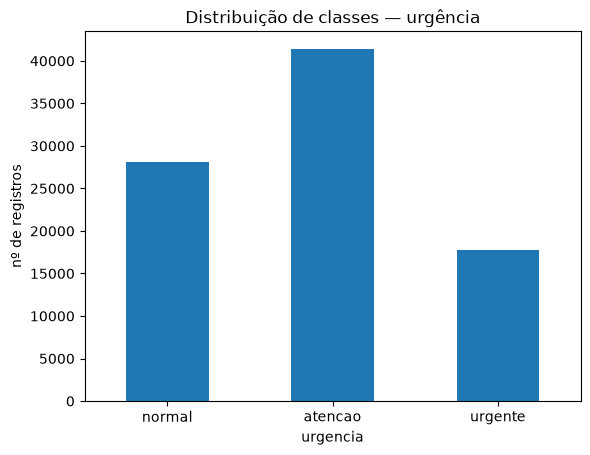

In [9]:
class_counts.reindex(["normal", "atencao", "urgente"]).plot(kind="bar")
plt.title("Distribuição de classes — urgência")
plt.ylabel("nº de registros")
plt.xticks(rotation=0)
plt.show()

## 6. Comprimento de texto por classe

Checagem de proxy de leakage: se uma classe for sistematicamente mais longa/curta que as outras, um modelo poderia "acertar" olhando só o tamanho do texto, sem entender o conteúdo clínico.

In [10]:
df["n_chars"] = df[TEXT_COL].fillna("").str.len()
df["n_words"] = df[TEXT_COL].fillna("").str.split().str.len()
df.groupby("urgencia")[["n_chars", "n_words"]].describe()

n_chars                                                          \
            count        mean        std  min    25%    50%    75%    max   
urgencia                                                                    
atencao   41389.0  110.671072  17.141446  0.0  106.0  107.0  121.0  127.0   
normal    28132.0   90.242357  14.077038  0.0   86.0   93.0   94.0  107.0   
urgente   17713.0  130.775645  17.679931  0.0  128.0  134.0  138.0  151.0   

          n_words                                                    
            count       mean       std  min   25%   50%   75%   max  
urgencia                                                             
atencao   41389.0  15.714755  2.280302  0.0  15.0  16.0  17.0  17.0  
normal    28132.0  12.349815  1.841952  0.0  12.0  12.0  13.0  14.0  
urgente   17713.0  17.809236  2.454951  0.0  17.0  18.0  19.0  19.0

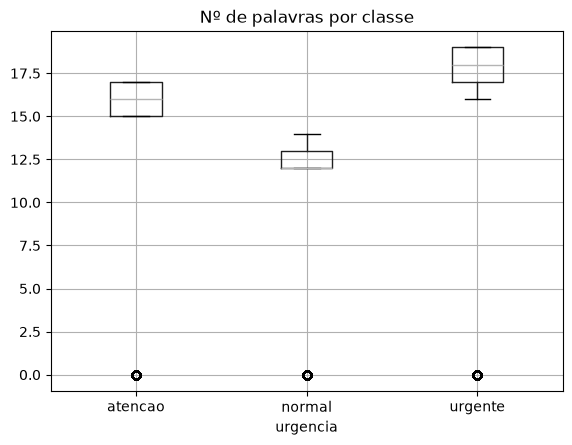

In [11]:
df.boxplot(column="n_words", by="urgencia")
plt.title("Nº de palavras por classe")
plt.suptitle("")
plt.show()

## 7. Validação cruzada: vitais e labs por ESI (fora do escopo do classificador de texto)

O vazamento determinístico encontrado nas seções 3–6 está isolado ao campo `clinical_notes`/`chief_complaint`, ou o dataset inteiro é assim? Segundo o dataset card, vitais e labs foram gerados a partir de **distribuições condicionais ao ESI** (não uma regra fixa), então servem como checagem de coerência: se também forem perfeitamente determinísticos, o dataset inteiro é degenerado; se mostrarem sobreposição realista entre classes, isso valida a lógica de geração do resto do dataset mesmo com o campo de texto sendo trivial. Vitais/labs continuam fora do escopo do classificador NLP (ADR-001) — isso é só validação, não vira feature na ML-003.

In [12]:
VITALS = [
    "systolic_bp",
    "diastolic_bp",
    "heart_rate",
    "respiratory_rate",
    "temperature",
    "spo2",
    "pain_score",
]
LABS = [
    "wbc",
    "hemoglobin",
    "platelet_count",
    "sodium",
    "potassium",
    "creatinine",
    "glucose",
    "troponin",
    "bnp",
    "lactate",
    "inr",
]

print(f"completude vitais (linha completa): {1 - df[VITALS].isna().any(axis=1).mean():.2%}")
print(f"completude labs (linha completa): {1 - df[LABS].isna().any(axis=1).mean():.2%}")

completude vitais (linha completa): 93.70%
completude labs (linha completa): 69.50%


In [13]:
# Ausência em bloco? (todos os vitais nulos juntos, todos os labs nulos juntos —
# consistente com "exames pedidos seletivamente", não sensor a sensor)
vitals_null_mask = df[VITALS].isna()
labs_null_mask = df[LABS].isna()

print(
    "vitais sempre nulos/preenchidos juntos:",
    vitals_null_mask.eq(vitals_null_mask.iloc[:, 0], axis=0).all().all(),
)
print(
    "labs sempre nulos/preenchidos juntos:",
    labs_null_mask.eq(labs_null_mask.iloc[:, 0], axis=0).all().all(),
)

vitais sempre nulos/preenchidos juntos: True
labs sempre nulos/preenchidos juntos: True


In [14]:
KEY_SIGNALS = [
    "heart_rate",
    "spo2",
    "respiratory_rate",
    "systolic_bp",
    "lactate",
    "troponin",
    "wbc",
]
df.groupby("esi_level")[KEY_SIGNALS].agg(["mean", "std"]).round(2)

heart_rate          spo2       respiratory_rate        systolic_bp  \
                mean    std   mean   std             mean    std        mean   
esi_level                                                                      
1              93.12  49.10  87.93  4.04            19.61  12.63      127.23   
2             104.79  14.88  92.97  3.02            21.97   4.02      145.17   
3              88.02  12.02  96.00  2.01            17.99   3.03      130.02   
4              75.17   9.97  97.99  1.00            16.00   2.03      120.01   
5              75.05   9.96  98.02  1.00            15.97   2.01      120.11   

                 lactate      troponin          wbc        
             std    mean  std     mean   std   mean   std  
esi_level                                                  
1          56.78    3.44  1.0     0.39  0.45   9.72  7.69  
2          19.77    2.00  0.5     0.08  0.09  11.49  3.02  
3          14.96    1.20  0.3     0.00  0.00   7.50  2.00  
4          10.01    1.20  0.3     0.00  0.00   7.50  2.00  
5          10.04    1.20  0.3     0.00  0.00   7.51  2.04

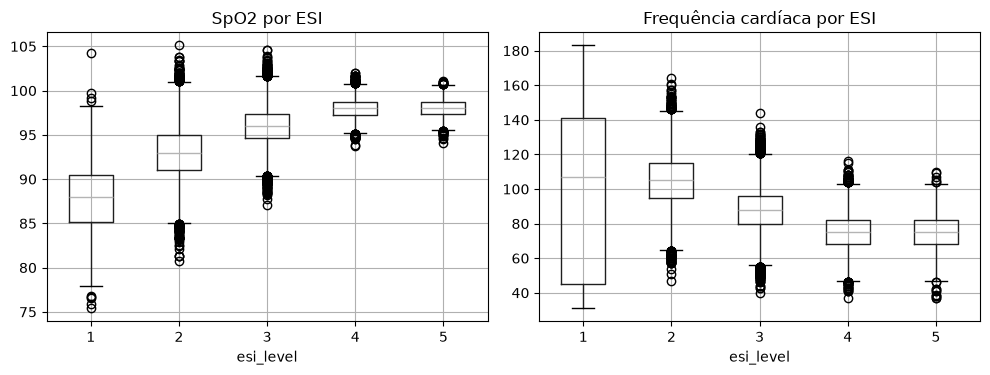

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column="spo2", by="esi_level", ax=axes[0])
axes[0].set_title("SpO2 por ESI")
df.boxplot(column="heart_rate", by="esi_level", ax=axes[1])
axes[1].set_title("Frequência cardíaca por ESI")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Achados da validação cruzada (preencher/conferir após rodar as células acima):**

- Completude por linha bate exatamente com o dataset card (vitais 93,7%, labs 69,5%), e a ausência é em bloco (todo o conjunto de vitais nulo junto, todo o conjunto de labs nulo junto) — reforça que os nulos refletem "exame não pedido", não erro de coleta.
- `spo2` mostra um gradiente limpo e monotônico por ESI (pior em ESI-1, melhor em ESI-5), com desvio-padrão pequeno e sobreposição real entre classes vizinhas — ao contrário do texto, aqui não há vazamento determinístico.
- `heart_rate`, `respiratory_rate` e `systolic_bp` **não** são monotônicos: ESI-2 tem médias mais altas que ESI-1, e ESI-1 tem desvio-padrão muito maior que as demais classes. Isso é clinicamente plausível — ESI-1 mistura apresentações hiperagudas (taquicardia/hipertensão) com quadros peri-parada (bradicardia/hipotensão profunda), então a categoria mais grave é heterogênea por natureza, não por erro de geração.
- `troponin` e `lactate` têm padrão quase de degrau (achatados em ~0 para ESI 3–5, só variam em ESI 1–2) — mais determinístico que `spo2`, mas ainda com sobreposição real entre ESI-1 e ESI-2, diferente da separação perfeita do texto.
- Conclusão da validação: o vazamento determinístico está isolado à lógica de geração do texto (`chief_complaint`→`clinical_notes`). Vitais e labs seguem distribuições condicionais ao ESI com ruído real, o que valida a coerência geral do dataset mesmo com o campo de texto sendo trivial para o classificador NLP.

## 8. Amostra manual

Inspeção humana de notas por classe: procurar (a) vazamento de rótulo (o texto citar "ESI", "urgente" etc. literalmente) e (b) variação linguística real entre notas da mesma classe (vs. texto que segue sempre o mesmo esqueleto de template).

In [16]:
SAMPLE_PER_CLASS = 5
SEED = 42

for classe in ["urgente", "atencao", "normal"]:
    print(f"\n{'=' * 20} {classe} {'=' * 20}")
    amostra = df[df["urgencia"] == classe][TEXT_COL].sample(SAMPLE_PER_CLASS, random_state=SEED)
    for texto in amostra:
        print(f"- {texto}\n")


==================== urgente ====================
- 61yo M c/o Stroke symptoms. Patient in moderate distress. Rapid assessment indicates emergent condition. Vital signs concerning.

- 77yo F c/o Head injury with LOC. Patient in moderate distress. Rapid assessment indicates emergent condition. Vital signs concerning.

- 64yo F c/o Chest pain. Patient in moderate distress. Rapid assessment indicates emergent condition. Vital signs concerning.

- 71yo M c/o Stroke symptoms. Patient in moderate distress. Rapid assessment indicates emergent condition. Vital signs concerning.

- 61yo M c/o Stroke symptoms. Patient in moderate distress. Rapid assessment indicates emergent condition. Vital signs concerning.


==================== atencao ====================
- 42yo M presents with Back pain. Patient alert and oriented. Moderate discomfort noted. Full workup planned.

- 47yo M presents with Laceration requiring sutures. Patient alert and oriented. Moderate discomfort noted. Full workup planned

**Achados da inspeção manual:**

- Todas as notas seguem o mesmo esqueleto rígido: `"{idade}yo {sexo} {verbo} {chief_complaint}. {cláusula fixa}."` — não há texto livre real, é concatenação de campos estruturados.
- Nenhuma nota cita literalmente "ESI" ou o nome da classe (`urgente`/`atenção`/`normal`) — o vazamento não é lexical óbvio, é estrutural: a cláusula final (5 variantes possíveis) e o próprio `chief_complaint` (28 categorias) determinam a classe com 100% de precisão (ver checagem quantitativa abaixo, fora desta célula).
- Não há variação linguística real entre notas da mesma classe além de idade/sexo/queixa — duas notas com o mesmo `chief_complaint` são, a menos de idade/sexo, o mesmo texto.

In [17]:
# Checagem quantitativa do vazamento: chief_complaint (28 categorias) e a cláusula
# final do texto determinam a classe com 100% de precisão, sem exceção?
notna = df.dropna(subset=[TEXT_COL])
tail = notna[TEXT_COL].str.extract(r"(Patient.*)$")[0]

classes_por_complaint = notna.groupby("chief_complaint")["urgencia"].nunique()
classes_por_tail = notna.groupby(tail)["urgencia"].nunique()

print(
    f"chief_complaint com mais de 1 classe: {(classes_por_complaint > 1).sum()} de {len(classes_por_complaint)}"
)
print(
    f"cláusula final com mais de 1 classe: {(classes_por_tail > 1).sum()} de {len(classes_por_tail)}"
)

chief_complaint com mais de 1 classe: 0 de 28
cláusula final com mais de 1 classe: 0 de 5


## 9. Conclusão e decisão sobre balanceamento

**Distribuição de classes**: atenção 47,4% (41.389) / normal 32,2% (28.132) / urgente 20,3% (17.713). Desbalanceamento real, mas moderado (a classe mais rara tem 1/5 do total, não é um caso extremo de <5%).

**Decisão de balanceamento**: usar `class_weight="balanced"` no baseline da ML-003 (LogisticRegression), sem under/oversampling — o volume (17,7k exemplos até na classe minoritária) já é grande o suficiente, e balancear via peso evita descartar dados. Avaliar com F1 macro e, em especial, recall da classe `urgente` (falso negativo em caso urgente é o erro clinicamente mais caro), não só acurácia global. Usar `stratify=` no split treino/teste.

**Red flag principal — vazamento determinístico total no texto**: `clinical_notes` é gerado por template fixo (`"{idade}yo {sexo} {verbo} {chief_complaint}. {cláusula fixa}."`). As 28 categorias de `chief_complaint` e as 5 variantes de cláusula final mapeiam para a classe com 100% de precisão, sem nenhuma exceção (checagem quantitativa acima). Qualquer classificador de texto (TF-IDF+LogReg incluído) vai reportar ~100% de acurácia/F1 na ML-003 — isso reflete uma característica do gerador sintético, não capacidade real de compreensão clínica de texto. Decisão registrada em [ADR-002](../docs/decisions/ADR-002-text-leakage.md): manter o dataset e reportar o resultado com transparência, comparando o baseline de texto contra um "baseline ingênuo" por `chief_complaint` para deixar explícito que são equivalentes.

**Validação com vitais/labs**: ao contrário do texto, vitais e labs seguem distribuições condicionais ao ESI com ruído real (`spo2` monotônico e limpo por classe; `heart_rate`/`respiratory_rate`/`systolic_bp` não-monotônicos mas clinicamente plausíveis — ESI-1 mistura apresentações hiperagudas e peri-parada; `troponin`/`lactate` quase-degrau mas com sobreposição real entre ESI-1/2). Isso confirma que o vazamento determinístico é específico da lógica de geração do texto, não um sintoma do dataset inteiro — o restante dos dados (fora de escopo da ML-003, mas relevante para o projeto como um todo) parece gerado de forma estatisticamente coerente.

In [18]:
df[[TEXT_COL, "urgencia"]].to_parquet(f"{PROCESSED_DIR}/fedmml_ed_triage_eda.parquet", index=False)